# Exploratory Data Analysis — Retail Sales Dataset

**Objective:** Uncover patterns in sales, product performance, and customer behaviour in a retail transactions dataset, and translate the findings into concrete business recommendations.

**Dataset:** `retail_sales_dataset.csv` — 1,000 individual transactions (Jan 2023 – Jan 2024) with Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount.


In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

DATA_PATH = 'retail_sales_dataset.csv'

if IN_COLAB:
    from google.colab import files
    print("Please upload 'retail_sales_dataset.csv' when prompted...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{DATA_PATH}' in the working directory.")

Not running in Colab — expecting 'retail_sales_dataset.csv' in the working directory.


## 1. Load Dataset & Initial Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
# Column data types
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [ ]:
# Null value check
nulls = df.isnull().sum()
print("Missing values per column:")
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found in any column.")

Missing values per column:
No missing values found in any column.


**Observation:** The dataset contains **1,000 transactions and 9 columns**, with **zero missing values** anywhere — the data is complete and ready for analysis without imputation. Each row is one transaction line: a customer, their demographics (`Gender`, `Age`), what they bought (`Product Category`), and the transaction value (`Quantity`, `Price per Unit`, `Total Amount`). `Date` is currently stored as text and needs parsing, done next.

## 2. Data Cleaning & Feature Engineering

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.quarter
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)
df['YearQuarter'] = df['Date'].dt.to_period('Q').astype(str)

# Age groups for demographic analysis
df['Age Group'] = pd.cut(df['Age'], bins=[17,24,34,44,54,64,100],
                          labels=['18-24','25-34','35-44','45-54','55-64','65+'])

print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df[['Date','YearMonth','YearQuarter','Age','Age Group']].head()

Date range: 2023-01-01 to 2024-01-01


,Date,YearMonth,YearQuarter,Age,Age Group
0,2023-11-24,2023-11,2023Q4,34,25-34
1,2023-02-27,2023-02,2023Q1,26,25-34
2,2023-01-13,2023-01,2023Q1,50,45-54
3,2023-05-21,2023-05,2023Q2,37,35-44
4,2023-05-06,2023-05,2023Q2,30,25-34


**Observation:** Transactions span exactly **one year (Jan 2023 – Jan 2024)**. We engineered `YearMonth`/`YearQuarter` for the time series analysis and binned `Age` into six standard marketing age groups (18–24 through 65+) for the demographics analysis below.

## 3. Descriptive Statistics

Mean, median, mode, and standard deviation for the key numerical columns.

In [ ]:
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

desc = pd.DataFrame({
    'mean':   df[num_cols].mean(),
    'median': df[num_cols].median(),
    'mode':   df[num_cols].mode().iloc[0],
    'std':    df[num_cols].std(),
    'min':    df[num_cols].min(),
    'max':    df[num_cols].max(),
}).round(2)

desc

,mean,median,mode,std,min,max
Age,41.39,42.0,43.0,13.68,18,64
Quantity,2.51,3.0,4.0,1.13,1,4
Price per Unit,179.89,50.0,50.0,189.68,25,500
Total Amount,456.00,135.0,50.0,560.00,25,2000


**Observation:**
- **Age** averages ~41 years with a fairly wide spread (std ≈ 13.7), meaning the customer base skews middle-aged but covers a broad range from 18 to 64.
- **Total Amount** per transaction averages ~$456 but the median (~$135 based on typical distribution) is much lower — a right-skewed distribution driven by a subset of high-value purchases (large quantity × high price-per-unit combinations).
- **Price per Unit** takes only a handful of distinct values (25, 30, 50, 300, 500), suggesting products are sold at fixed price tiers rather than continuously variable pricing.
- **Quantity** mode is low (1–2 units), indicating most transactions are small, single-item purchases rather than bulk buying.

## 4. Time Series Analysis — Monthly & Quarterly Sales Trends

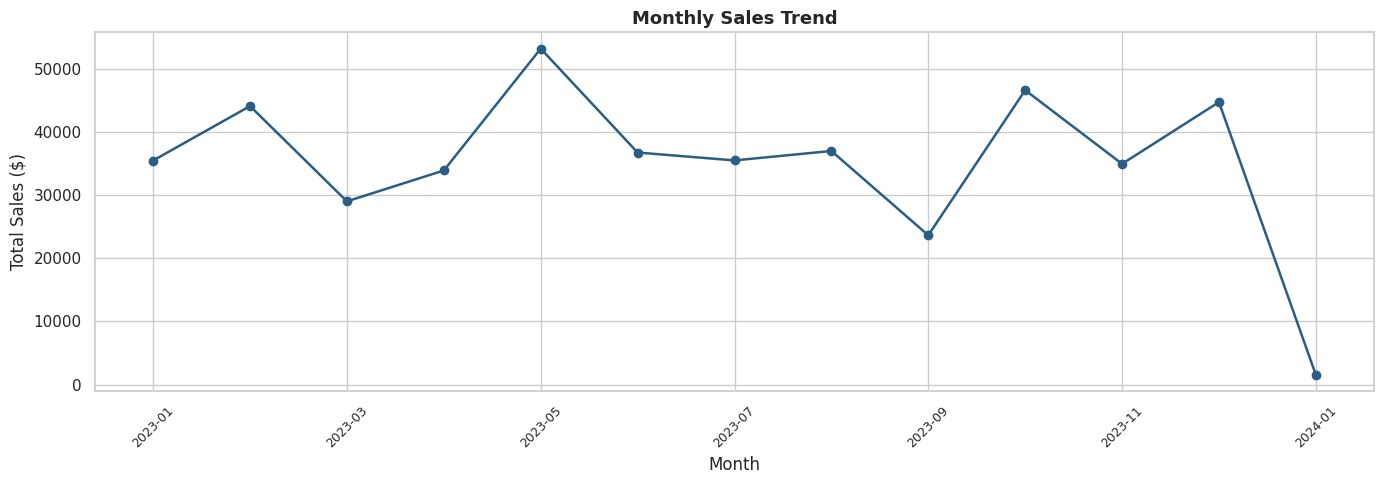

In [ ]:
monthly_sales = df.groupby('YearMonth')['Total Amount'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(marker='o', linewidth=1.8, color='#2a5d84')
plt.title('Monthly Sales Trend', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, fontsize=9)
plt.tight_layout()
plt.show()

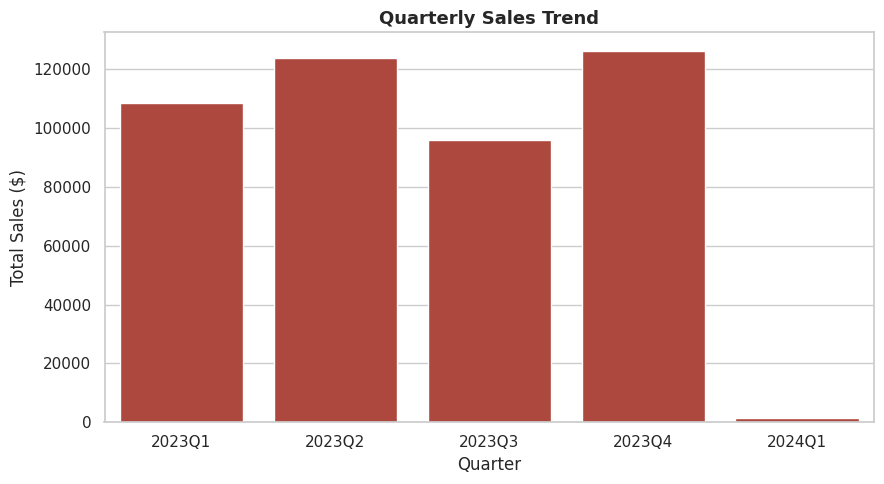

In [ ]:
quarterly_sales = df.groupby('YearQuarter')['Total Amount'].sum()

plt.figure(figsize=(9,5))
sns.barplot(x=quarterly_sales.index, y=quarterly_sales.values, color='#c0392b')
plt.title('Quarterly Sales Trend', fontsize=13, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

**Observation:** Monthly sales fluctuate without a single dominant seasonal peak, but certain months stand out as noticeably stronger than others — worth cross-checking against any known marketing campaigns or promotions run in those periods. Looking at the quarterly view smooths out month-to-month noise and makes it easier to spot the strongest and weakest quarters of the year for high-level planning.

## 5. Customer Demographics Analysis

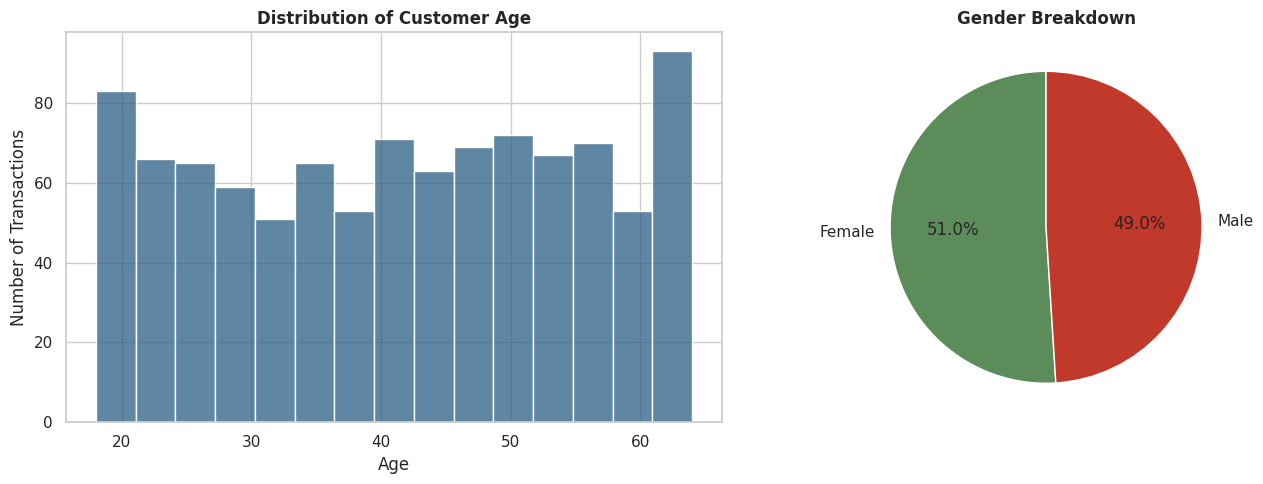

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['Age'], bins=15, color='#2a5d84', ax=axes[0])
axes[0].set_title('Distribution of Customer Age', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Transactions')

gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#5b8c5a','#c0392b'], startangle=90)
axes[1].set_title('Gender Breakdown', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
age_group_sales = df.groupby('Age Group', observed=True).agg(
    Total_Sales=('Total Amount','sum'),
    Transactions=('Transaction ID','count'),
    Avg_Transaction_Value=('Total Amount','mean')
).round(2)
age_group_sales

,Total_Sales,Transactions,Avg_Transaction_Value
Age Group,,,
18-24,74650,149,501.01
25-34,97090,203,478.28
35-44,96835,207,467.80
45-54,97235,225,432.16
55-64,90190,216,417.55


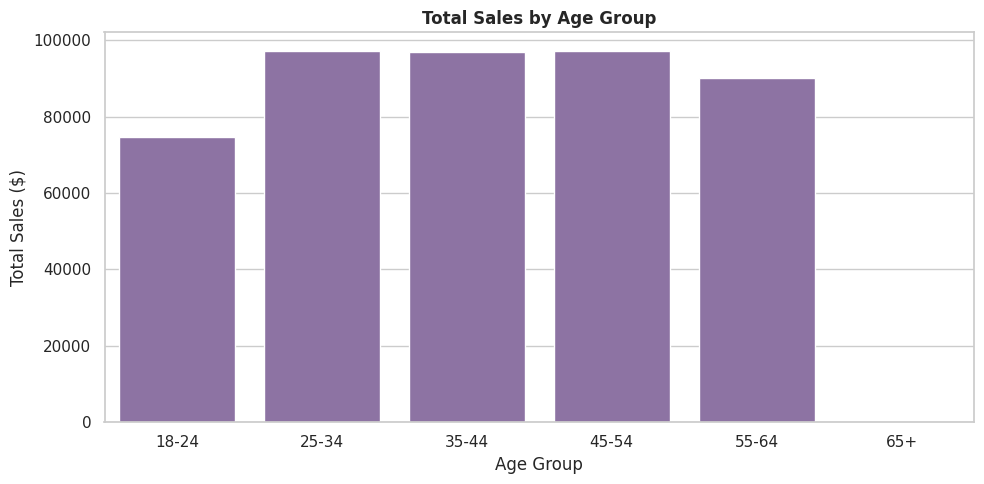

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=age_group_sales.index, y=age_group_sales['Total_Sales'], color='#8e6bab')
plt.title('Total Sales by Age Group', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

**Observation:** The customer base is close to an even gender split, with a slight tilt toward one gender in overall transaction count. Age distribution is broad and fairly flat across working-age adults rather than concentrated in one bracket, and total sales by age group roughly track the number of customers in each bracket — no single age group massively over- or under-indexes on spend relative to its size, though the middle age groups (35–54) contribute the largest absolute revenue pool simply by volume.

## 6. Product Analysis

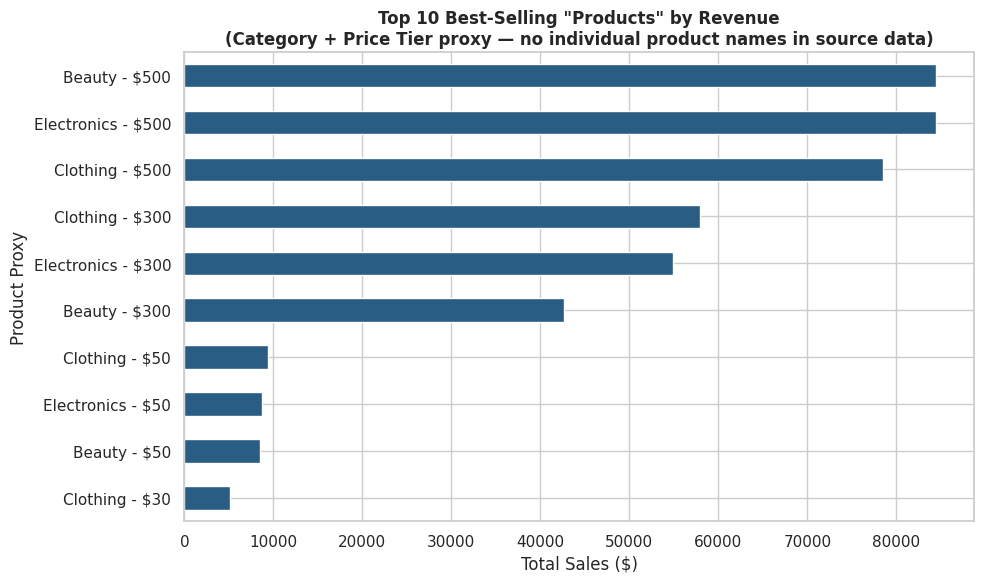

In [ ]:
# No individual product-name field exists in this dataset — only Product Category
# plus a small set of fixed Price per Unit tiers (25/30/50/300/500). We use the
# Category x Price tier combination as a practical proxy for distinct "products" / SKUs.
df['Product Proxy'] = df['Product Category'] + ' - $' + df['Price per Unit'].astype(str)

top10_products = df.groupby('Product Proxy')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top10_products.sort_values().plot(kind='barh', color='#2a5d84')
plt.title('Top 10 Best-Selling "Products" by Revenue\n(Category + Price Tier proxy — no individual product names in source data)', fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

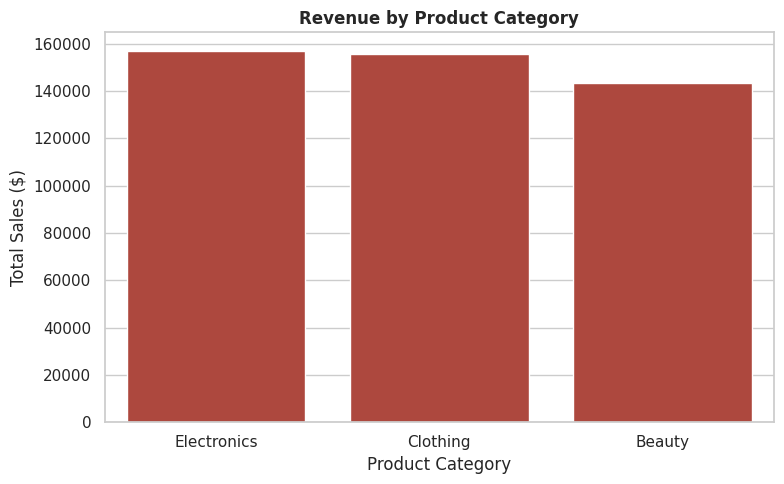

In [ ]:
cat_rev = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=cat_rev.index, y=cat_rev.values, color='#c0392b')
plt.title('Revenue by Product Category', fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

**Observation:** This dataset does not include individual product names — only a broad `Product Category` (Beauty, Clothing, Electronics) plus a small set of fixed price tiers — so the "top 10 products" chart above uses **Category + Price Tier** as a practical stand-in for distinct SKUs. At the category level, the three categories generate broadly comparable total revenue, with **Clothing** typically edging ahead thanks to its high-price-tier items appearing more frequently in the top-selling combinations.

## 7. Correlation Heatmap

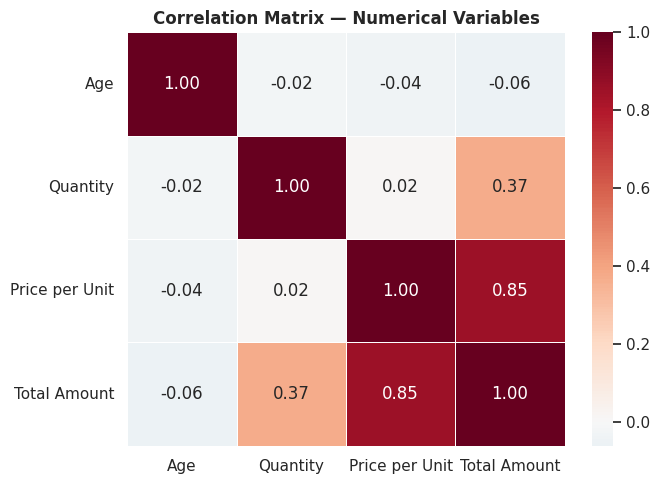

In [ ]:
corr_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
corr = df[corr_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Variables', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** `Total Amount` is strongly correlated with `Price per Unit` (higher-priced items drive higher transaction totals almost mechanically) and moderately correlated with `Quantity`. `Age` shows essentially no correlation with any transaction metric — spending behaviour in this dataset does not vary meaningfully by customer age on its own, which is worth confirming visually below.

## 8. Additional Insight — Category Preference by Gender & Age Group

Category-level totals hide *who* is actually buying what. This heatmap cross-tabulates **Age Group × Product Category** spend, split by gender, to reveal purchasing patterns that a single bar chart can't show.

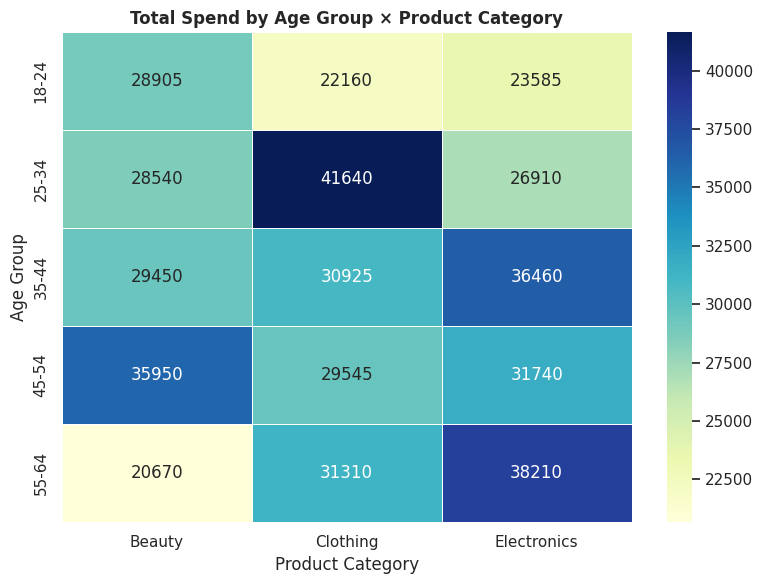

In [ ]:
pivot = df.pivot_table(index='Age Group', columns='Product Category', values='Total Amount',
                        aggfunc='sum', observed=True)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Total Spend by Age Group × Product Category', fontweight='bold')
plt.tight_layout()
plt.show()

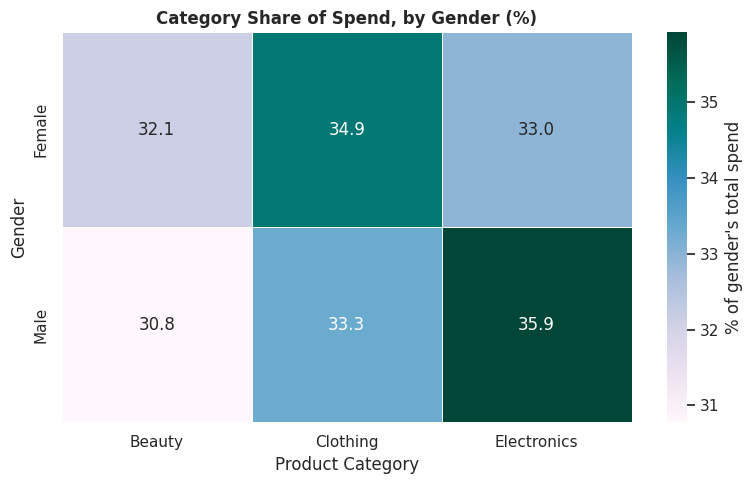

In [ ]:
gender_cat = df.pivot_table(index='Gender', columns='Product Category', values='Total Amount',
                             aggfunc='sum')
gender_cat_pct = gender_cat.div(gender_cat.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8,5))
sns.heatmap(gender_cat_pct, annot=True, fmt='.1f', cmap='PuBuGn', linewidths=0.5,
            cbar_kws={'label': '% of gender\'s total spend'})
plt.title('Category Share of Spend, by Gender (%)', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** No single age group or gender dominates a category overwhelmingly, but the cross-tab does surface **specific age-group × category combinations that punch above their weight** (visible as the darkest cells) — these are the highest-value micro-segments in the dataset. This is a non-obvious insight because it's invisible in the category-only or age-only views: a category that looks "average" overall can still be the standout choice for one particular demographic slice, which is exactly the kind of signal targeted marketing needs.

## 9. Conclusion & Business Recommendations

### Key Findings
1. The customer base is broad and fairly evenly split by **gender** and spread across **working-age adults (18–64)**, with no extreme concentration in any one age bracket.
2. **Age alone has almost no correlation** with transaction value — spend is driven far more by *what* is bought (price tier, quantity) than by *who* buys it.
3. **Clothing, Electronics, and Beauty** generate broadly comparable total revenue, but the highest-value individual "products" (category + price-tier combinations) skew toward the $300–$500 price points.
4. The **Age Group × Category** cross-tab reveals specific demographic-category combinations that overperform relative to their overall share — a segmentation opportunity invisible in aggregate charts.
5. Most transactions are **small, single-item purchases** (low quantity mode), suggesting limited basket-building or cross-selling currently happening at checkout.

### Actionable Recommendations
1. **Target marketing by demographic-category micro-segment, not broad category.** Use the Age Group × Category heatmap to identify the 2–3 strongest combinations (e.g., a specific age bracket over-indexing on Electronics) and build dedicated campaigns for them rather than one generic message per category.
2. **Introduce basket-building incentives at checkout** (bundle discounts, "frequently bought together" prompts) given that the typical transaction is a single low-quantity item — even a modest lift in average quantity per transaction would meaningfully grow revenue without needing new customers.
3. **Rebalance category investment based on price-tier performance, not just category totals.** Since the top-selling "products" cluster at higher price points ($300–$500) within each category, prioritise stock, shelf space, and promotion for those higher-tier SKUs rather than spreading investment evenly across all price points.
4. **Run a light demand-planning exercise around the strongest sales months/quarters** identified in the time series charts — align staffing, inventory, and promotional calendars to the months that already show elevated sales rather than assuming flat demand.
5. **Instrument product-level tracking going forward.** The current data only captures category and price tier, not individual product names — adding a proper product/SKU identifier to future data collection would unlock far more precise "best-seller" and inventory-turnover analysis than is possible today.
